In [1]:
from tinygrad import Device
import matplotlib.pyplot as plt
print(Device.DEFAULT)


METAL


In [2]:
from tinygrad import Tensor, nn 
class Model: 
    def __init__(self):
        self.l1 = nn.Conv2d(1, 32, kernel_size = (3, 3))
        self.l2 = nn.Conv2d(32, 64, kernel_size = (3, 3))
        # (H_in - kH + 2*padding)//stride + 1 (how to know output feature map's H and W)
        # 28 - 3 / 1 + 1  = 26 feature map size 
        # 26 - 3 +
        self.l3 = nn.Linear(1600, 10)
    def __call__(self, x:Tensor) -> Tensor: 
        x = self.l1(x).relu().max_pool2d((2, 2))
        x = self.l2(x).relu().max_pool2d((2, 2))
        return self.l3(x.flatten(1).dropout(0.5))
        

In [3]:
from tinygrad.nn.datasets import mnist
X_train, Y_train, X_test, Y_test = mnist()
print(X_train.shape, X_train.dtype, Y_train.shape, Y_train.dtype)


(60000, 1, 28, 28) dtypes.uchar (60000,) dtypes.uchar


In [4]:
model = Model() 
acc = (model(X_test).argmax(axis=1) == Y_test).mean()
print(acc.item())  # ~10% accuracy, as expected from a random model


0.07779999822378159


In [5]:
optim = nn.optim.Adam(nn.state.get_parameters(model)) 
batch_size = 128 
def step():
    Tensor.training = True 
    samples = Tensor.randint(batch_size, high=X_train.shape[0])
    X, Y = X_train[samples], Y_train[samples]
    optim.zero_grad() 
    loss = model(X).sparse_categorical_crossentropy(Y).backward()
    optim.step()
    return loss

In [6]:
import timeit
timeit.repeat(step, repeat=5, number=1)


[2.7939602499827743,
 1.2203279999957886,
 0.2224649169947952,
 0.2174421660020016,
 0.22224208299303427]

In [7]:
from tinygrad import GlobalCounters, Context
GlobalCounters.reset()
with Context(DEBUG=2): step()


scheduled 56 kernels in 174.05 ms
*** METAL      1 En10                                           arg  1 mem   0.06 GB tm     10.25us/     0.01ms (      0 GFLOPS    0|0      GB/s) ['__imul__']
*** METAL      2 En11                                           arg  1 mem   0.06 GB tm      6.87us/     0.02ms (      0 GFLOPS    0|0      GB/s) ['__imul__']
*** METAL      3 En6                                            arg  1 mem   0.06 GB tm      7.00us/     0.02ms (      0 GFLOPS    0|0      GB/s) ['randint']
*** METAL      4 E_32_4                                         arg  3 mem   0.06 GB tm     25.75us/     0.05ms (      1 GFLOPS    0|0      GB/s) ['randint']
*** METAL      5 En9                                            arg  2 mem   0.06 GB tm      6.75us/     0.06ms (      0 GFLOPS    0|0      GB/s) ['dropout']
*** METAL      6 E_32_49_5_4_16_2_4                             arg  3 mem   0.06 GB tm    175.13us/     0.23ms (      0 GFLOPS   46|46     GB/s) ['randint', '__getitem__']
*

In [8]:
from tinygrad import TinyJit
jit_step = TinyJit(step)

In [9]:
import timeit
timeit.repeat(jit_step, repeat=5, number=1)

[0.27178450001520105,
 0.23971749999327585,
 0.00200899998890236,
 0.037583750003250316,
 0.022079833026509732]

In [10]:
for step in range(2000):
  loss = jit_step()
  if step%100 == 0:
    Tensor.training = False
    acc = (model(X_test).argmax(axis=1) == Y_test).mean().item()
    print(f"step {step:4d}, loss {loss.item():.2f}, acc {acc*100.:.2f}%")

step    0, loss 2.40, acc 75.14%
step  100, loss 0.21, acc 95.56%
step  200, loss 0.27, acc 97.05%
step  300, loss 0.21, acc 97.64%
step  400, loss 0.11, acc 97.67%
step  500, loss 0.15, acc 97.81%
step  600, loss 0.10, acc 98.25%
step  700, loss 0.13, acc 98.12%
step  800, loss 0.09, acc 97.97%
step  900, loss 0.09, acc 98.17%
step 1000, loss 0.13, acc 98.49%
step 1100, loss 0.08, acc 98.52%
step 1200, loss 0.03, acc 98.31%
step 1300, loss 0.05, acc 98.46%
step 1400, loss 0.07, acc 98.55%
step 1500, loss 0.17, acc 98.31%
step 1600, loss 0.05, acc 98.44%
step 1700, loss 0.10, acc 98.68%
step 1800, loss 0.07, acc 98.43%
step 1900, loss 0.10, acc 98.61%


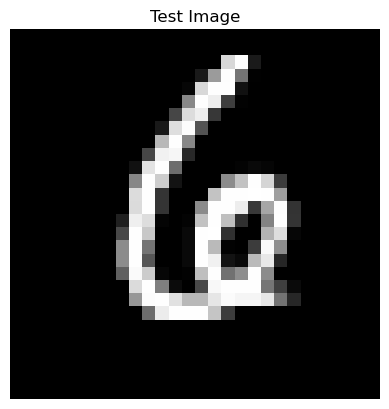

模型预测结果: 6
真实标签: 6


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from tinygrad import Tensor

index = 123

# 取出 tinygrad Tensor 并转换成 numpy
image = X_test[index].numpy().reshape(28,28)  # reshape 去掉 channel

# 显示图片
plt.imshow(image, cmap='gray')
plt.title("Test Image")
plt.axis('off')
plt.show()

# 推理
x = X_test[index].reshape(1,1,28,28)  # 保持 tinygrad Tensor 格式
output = model(x)
pred = output.argmax(axis=1).item()

print("模型预测结果:", pred)
print("真实标签:", Y_test[index].numpy().item())

